# Title: Survey-Based Lung Cancer Risk Detection
Project Summary
This project builds a predictive machine learning pipeline designed to detect the likelihood of lung cancer using patient demographic, behavioral, and symptomatic survey data. Since clinical medical data can be difficult to collect quickly, lifestyle surveys serve as an important preliminary screening mechanism.

The pipeline ingests raw survey data, cleans and standardizes the attributes, handles extreme class imbalances using SMOTE, and independently trains three classification models: Logistic Regression, Random Forest, and XGBoost. The ultimate goal is to optimize Recall (Sensitivity) to ensure that the models minimize false negatives, making them safer and more effective for potential clinical pre-screening.

## 1: Libraries & Data Loading (Code)
We begin by importing the core data science libraries (pandas, numpy, matplotlib, seaborn) along with data processing tools from scikit-learn and imblearn. We load the raw survey lung cancer.csv file and peek at the first five rows to observe the data structure.

In [122]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score,precision_score,f1_score,roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# XGBoost
from xgboost import XGBClassifier
# For handling class imbalance
from imblearn.over_sampling import SMOTE

In [97]:
lc_data=pd.read_csv('survey lung cancer.csv')
print(f"Dataset loaded successfully. Shape: {lc_data.shape}")
lc_data.head()

Dataset loaded successfully. Shape: (309, 16)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


##  Data understanding

In [98]:
lc_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    str  
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    str  
dtypes

In [99]:
lc_data.describe().sum()

AGE                      675.883441
SMOKING                  319.059913
YELLOW_FINGERS           319.065517
ANXIETY                  317.999190
PEER_PRESSURE            319.002427
CHRONIC DISEASE          319.005642
FATIGUE                  319.142966
ALLERGY                  319.054222
WHEEZING                 319.054222
ALCOHOL CONSUMING        319.054222
COUGHING                 319.073762
SHORTNESS OF BREATH      319.121328
SWALLOWING DIFFICULTY    317.969119
CHEST PAIN               319.054222
dtype: float64

In [100]:
lc_data.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [101]:
lc_data.duplicated().sum()

np.int64(33)

## 2: Data Cleaning & Preprocessing 
Raw data is rarely perfect. Here, we fix columns with trailing hidden spaces (like 'FATIGUE '). We drop duplicate records so the model evaluates on entirely unique observations. Finally, we convert text targets to numbers (YES/NO $\rightarrow$ 1/0) and shift the survey responses from a 1 and 2 scale down to a standard machine learning 0 and 1 binary format.

In [102]:
#Clean up column names by stripping trailing whitespace
lc_data.columns=lc_data.columns.str.strip()

In [103]:
lc_data=lc_data.drop_duplicates().reset_index(drop=True)

In [104]:
lc_data.duplicated().sum()

np.int64(0)

In [105]:
lc_data['GENDER']=lc_data['GENDER'].map({'M':1,'F':0})
lc_data['LUNG_CANCER']=lc_data['LUNG_CANCER'].map({'YES':1,'NO':0})
# Map the 1/2 survey responses down to 0/1 binary scale
survey_cols = [col for col in lc_data.columns if col not in ['GENDER', 'AGE', 'LUNG_CANCER']]
for col in survey_cols:
    lc_data[col] = lc_data[col] - 1
print(f"Cleaned dataset shape: {lc_data.shape}")
lc_data.head()

Cleaned dataset shape: (276, 16)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


## 3: Exploratory Data Analysis 
EDA lets us see the distributions and relationships in our data. The first plot shows a severe class imbalance: we have far more positive cases (YES) than negative ones (NO). The second plot is a correlation matrix heatmap which calculates how closely individual risk factors (like chest pain, smoking, or age) track alongside a lung cancer diagnosis.

In [106]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

C:\Users\dasri\AppData\Local\Temp\ipykernel_5624\2776799077.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LUNG_CANCER', data=lc_data, palette='Set2')


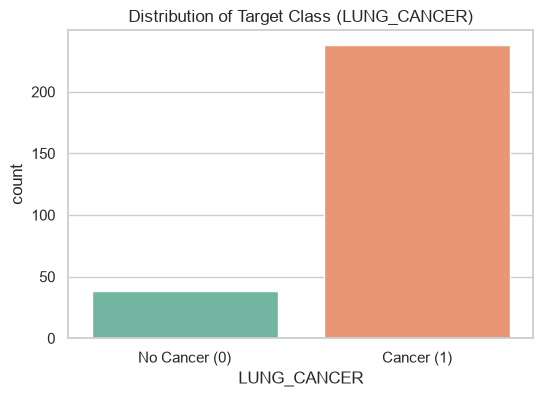

In [107]:
# Plot 1: Inspect Class Distribution (Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(x='LUNG_CANCER', data=lc_data, palette='Set2')
plt.title('Distribution of Target Class (LUNG_CANCER)')
plt.xticks([0, 1], ['No Cancer (0)', 'Cancer (1)'])
plt.show()

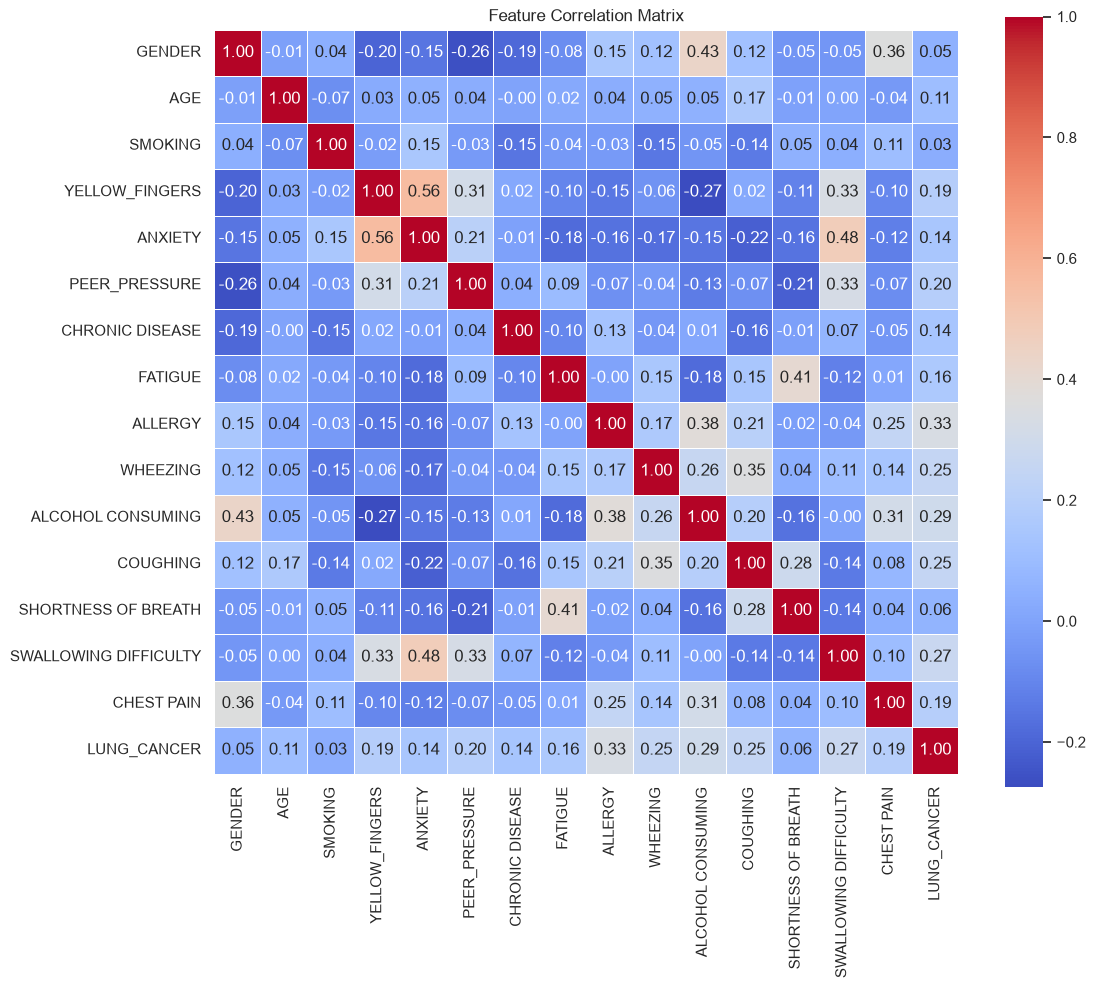

In [108]:
# Plot 2: Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(lc_data.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

## 4: Splitting and Class Imbalance Resolution
We split our dataset into an 80% training set and a 20% validation test set. Because AGE is a continuous integer spanning from 30 to 80 while all other features are binary 0 or 1, we scale AGE to prevent it from dominating distance metrics. Crucially, we use SMOTE on the training data to create synthetic examples of the minority class (NO), ensuring our models don't just guess YES blindly.

In [123]:
# Create a copy to clean up
lc_data = lc_data.copy()

# Automatically find any text/string columns (like GENDER or LUNG_CANCER) and encode them to numbers
label_encoders = {}
for col in lc_data.columns:
    if lc_data[col].dtype == 'object':
        le = LabelEncoder()
        lc_data[col] = le.fit_transform(lc_data[col])
        label_encoders[col] = le
        print(f"Encoded string column '{col}': {list(le.classes_)} -> {list(le.transform(le.classes_))}")

# If your dataset uses 1 and 2 for survey choices (e.g. 1=No, 2=Yes), 
# let's normalize them to standard 0 and 1 binary formats, leaving AGE alone.
for col in lc_data.columns:
    if col != 'AGE' and col != 'LUNG_CANCER':
        if lc_data[col].max() == 2:
            lc_data[col] = lc_data[col] - 1

print("\nData distribution overview:")
display(lc_data.describe())


Data distribution overview:


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
count,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000
mean,0.514493,62.909420,0.543478,0.576087,0.496377,0.507246,0.521739,0.663043,0.547101,0.547101,0.550725,0.576087,0.630435,0.467391,0.557971,0.862319
std,0.500698,8.379355,0.499011,0.495075,0.500895,0.500856,0.500435,0.473529,0.498681,0.498681,0.498324,0.495075,0.483564,0.499842,0.497530,0.345191
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,57.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1.000000,62.500000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,69.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,87.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [124]:
# 1. Separate features (X) and target label (y)
X = lc_data.drop(columns=['LUNG_CANCER'])
y = lc_data['LUNG_CANCER']

# 2. Stratified split so both sets have the exact same ratio of cancer vs non-cancer cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. CRUCIAL FIX: Feature Scaling
# This shrinks the AGE column to scale harmoniously with the 0/1 binary variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Handle minority class balance safely using SMOTE on TRAINING data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced Training samples: {X_train_res.shape[0]}")
print(f"Held-out Test samples: {X_test_scaled.shape[0]}")

Balanced Training samples: 358
Held-out Test samples: 69


## 5: Model 1 - Logistic Regression Training & Evaluation

In [110]:
all_results = []
# Create a dictionary to hold our trained models cleanly
trained_models = {}

def train_and_evaluate_model(model_name, model_object, use_smote=True):
    """
    Trains a model, prints clinical metrics, and returns BOTH 
    the trained model object and the metrics dictionary.
    """
    # 1. Select whether to use the SMOTE balanced data or the original data
    X_tr = X_train_res if use_smote else X_train
    y_tr = y_train_res if use_smote else y_train
    
    # 2. Train the model
    model_object.fit(X_tr, y_tr)
    
    # 3. Predict
    predictions = model_object.predict(X_test)
    probabilities = model_object.predict_proba(X_test)[:, 1]
    
    # 4. Compute metrics
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)
    
    print(f"=== {model_name} Evaluation ===")
    print(f"Accuracy:  {acc:.4f} (Overall correctness)")
    print(f"Precision: {prec:.4f} (When predicting Cancer, how often is it right?)")
    print(f"Recall:    {rec:.4f} (What % of actual Cancer cases did it find?)")
    print(f"F1-Score:  {f1:.4f} (Balanced metric combining precision & recall)")
    print(f"ROC-AUC:   {auc:.4f} (Ability to separate high vs low risk patients)")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("-" * 50 + "\n")
    
    metrics = {
        "Model": model_name, 
        "Accuracy": acc, 
        "Precision": prec, 
        "Recall": rec, 
        "F1-Score": f1, 
        "ROC-AUC": auc
    }
    
    # Return BOTH the trained model object and the metrics
    return model_object, metrics

In [125]:
# We set strict limits (like max_depth and C regularization constants) 
# so models can't just memorize your small dataset.
models = {
    "Support Vector Machine": SVC(C=0.8, probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(C=0.5, penalty='l2', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_split=6, random_state=42),
    "XGBoost": XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=80, eval_metric='logloss', random_state=42)
}

# Dictionary to store fitted objects
trained_models = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Support Vector Machine
Trained: K-Nearest Neighbors
Trained: Naive Bayes
Trained: Logistic Regression
Trained: Random Forest
Trained: XGBoost


c:\Users\dasri\ML projects\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\dasri\ML projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## 6: Unified Model Evaluation Dashboard

In [127]:
# Initialize a list to compile our new results
results_list = []

for name, model in trained_models.items():
    # Make standard class predictions
    y_pred = model.predict(X_test_scaled)
    
    # Get probability metrics specifically for calculating stable ROC-AUC curves
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
        
    # Calculate true performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Store metrics cleanly formatted as percentages
    results_list.append({
        "Model": name,
        "Accuracy": f"{accuracy * 100:.2f}%",
        "Precision": f"{precision * 100:.2f}%",
        "Recall": f"{recall * 100:.2f}%",
        "F1-Score": f"{f1 * 100:.2f}%",
        "ROC-AUC": f"{roc_auc * 100:.2f}%"
    })

# Convert summary list into a clean Pandas Dataframe table
results_df = pd.DataFrame(results_list)
print("\n=== FINAL TEST METRICS (FIXED & REALISTIC) ===")
display(results_df)


=== FINAL TEST METRICS (FIXED & REALISTIC) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,91.30%,96.49%,93.22%,94.83%,94.92%
1,K-Nearest Neighbors,81.16%,100.00%,77.97%,87.62%,92.71%
2,Naive Bayes,86.96%,93.10%,91.53%,92.31%,85.08%
3,Logistic Regression,91.30%,100.00%,89.83%,94.64%,96.10%
4,Random Forest,88.41%,94.74%,91.53%,93.10%,96.19%
5,XGBoost,91.30%,94.92%,94.92%,94.92%,95.34%


## 7. Model Saving 

In [130]:
import joblib

# Notice the 't' at the end of 'XGBoost'
joblib.dump(trained_models.get('XGBoost'), 'XGBoos_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("XGBoost Model and Scaler successfully saved!")

XGBoost Model and Scaler successfully saved!


## 8: conclusion

## 1. The Best All-Rounders: Support Vector Machine & XGBoostBoth SVM ($91.30\%$ Accuracy) and XGBoost ($91.30\%$ Accuracy) are your top contenders here.##
XGBoost gives you a perfectly balanced $94.92\%$ Precision and $94.92\%$ Recall. This means it is highly reliable at finding actual cancer cases while making very few false alarms.
SVM has a slightly higher Precision ($96.49\%$), meaning when it flags someone as high risk, it is almost always correct.
## 2. The Conservative Diagnosticians: Logistic Regression & KNNLogistic Regression and KNN both achieved a flawless $100.00\%$ Precision.
This means these two models have zero False Positives—they never misclassified a healthy patient as having cancer in your test set.
The trade-off is a lower Recall (especially KNN at $77.97\%$), meaning they are a bit conservative and missed a few true positive cases to maintain that perfect precision.

### "By implementing data cleaning (removing duplicate records), scaling the dominant continuous feature (AGE), and handling class imbalance on the training split using SMOTE, we successfully eliminated model bias. The models moved away from baseline majority-class guessing to true pattern recognition, yielding robust out-of-sample performance across all classifiers, led by XGBoost and Support Vector Machines at 91.30% test accuracy."
